In [18]:
%load_ext autoreload
%autoreload 2

subj = "Subj1"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import typing

import mne
import numpy
import pandas
import IPython.display
import sklearn.metrics
import sklearn.preprocessing
import sklearn.decomposition
import matplotlib.pyplot as plt

import SDA.topology
import SDA.analytics
import SDA.clustquality
import SDA.stageprocess

In [20]:
def calc_topological(data):
    per_channel_extractor = SDA.topology.PerChannelFeatureExtractor(n_jobs = -1, reduced = True)
    per_channel_extractor.extract(data)

    overall_extractor = SDA.topology.OverallFeatureExtractor(n_jobs = -1, reduced = True)
    overall_extractor.extract(data)

In [21]:
def calc_traditional(raw_data, epochs, data):
    bands = [(0.9, 4, 'Delta (0.9-4 Hz)', 'D'), (4, 8, 'Theta (4-8 Hz)', 'T'), (8, 14, 'Alpha (8-14 Hz)', 'A'), 
            (14, 25, 'Beta (14-25 Hz)', 'B'), (25, 40, 'Gamma (25-40 Hz)', 'G')]

    str_freq = [bands[i][3] for i in range(len(bands))]
    str_freq_rr = str_freq
    n_freq = len(str_freq_rr)

    regions = [ ([ch_name], ch_name, ch_name) for ch_name in epochs.ch_names ]
    regions_plt = [ ([ch_name], ch_name, ch_name) for ch_name in epochs.ch_names ]

    n_regions = len(regions)
    n_regions_plt = len(regions_plt)

    sampling_rate = raw_data.info['sfreq']
    ch_names = epochs.ch_names
    n_freq = len(str_freq_rr)
    n_channels = len(ch_names)

    n_samples = data.__len__()
    n_times = len(data[0,0,:])

    import numpy as np
    import pandas as pd

    kwargs = dict(fmin=bands[0][0], fmax=bands[-1][1], sfreq=sampling_rate, bandwidth=None, adaptive=True, n_jobs=1)

    rr_psd_mtaper, rr_freq_mtaper = mne.time_frequency.psd_array_multitaper(data, verbose='error', **kwargs)
    freq_masks = [(fmin < rr_freq_mtaper) & (rr_freq_mtaper < fmax) for (fmin, fmax, _, _) in bands]
    loc_masks = [[ch_names[i] in reg for i in range(n_channels)] for (reg, _, _) in regions]
    loc_plt_masks = [[ch_names[i] in reg for i in range(n_channels)] for (reg, _, _) in regions_plt]
    # print(rr_freq_mtaper)
    # print(rr_psd_mtaper.shape)

    ft_psd_spectr_raw = np.array([np.mean(rr_psd_mtaper[:,:, _freq_mask], axis=2) for _freq_mask in freq_masks]).transpose(1,2,0)
    ft_psd_sp_loc_raw = np.array([np.mean(ft_psd_spectr_raw[:,_mask,:], axis=1) for _mask in loc_masks]).transpose(1,0,2)
    ft_psd_sp_plt_raw = np.array([np.mean(ft_psd_spectr_raw[:,_mask,:], axis=1) for _mask in loc_plt_masks]).transpose(1,0,2)
    ft_psd_sp_all_raw = np.mean(ft_psd_spectr_raw, axis=1)

    ft_psd_spectr_db = 10 * np.log10(ft_psd_spectr_raw) # Convert psd to dB format
    ft_psd_sp_loc_db = 10 * np.log10(ft_psd_sp_loc_raw) # Convert psd to dB 
    ft_psd_sp_plt_db = 10 * np.log10(ft_psd_sp_plt_raw) # Convert psd to dB format
    ft_psd_sp_all_db = 10 * np.log10(ft_psd_sp_all_raw) # Convert psd to dB format

    df_ft_psd_raw = pd.DataFrame()
    df_ft_psd_db = pd.DataFrame()
    df_ft_psd_loc_raw = pd.DataFrame()
    df_ft_psd_loc_db = pd.DataFrame()
    df_ft_psd_plt_raw = pd.DataFrame()
    df_ft_psd_plt_db = pd.DataFrame()
    df_ft_psd_all_raw = pd.DataFrame()
    df_ft_psd_all_db = pd.DataFrame()

    for i in range(n_freq):
        for j in range(n_channels):
            df_ft_psd_raw[str_freq_rr[i]+'_psd_'+ch_names[j]] = ft_psd_spectr_raw[:,j,i]
            df_ft_psd_db[str_freq_rr[i]+'_psd_'+ch_names[j]] = ft_psd_spectr_db[:,j,i]
        for j in range(n_regions):    
            df_ft_psd_loc_raw[str_freq_rr[i]+'_psd_'+regions[j][1]] = ft_psd_sp_loc_raw[:,j,i]
            df_ft_psd_loc_db[str_freq_rr[i]+'_psd_'+regions[j][1]] = ft_psd_sp_loc_db[:,j,i]
        for j in range(n_regions_plt):    
            df_ft_psd_plt_raw[str_freq_rr[i]+'_psd_'+regions_plt[j][1]] = ft_psd_sp_plt_raw[:,j,i]
            df_ft_psd_plt_db[str_freq_rr[i]+'_psd_'+regions_plt[j][1]] = ft_psd_sp_plt_db[:,j,i]
        df_ft_psd_all_raw[str_freq_rr[i]+'_psd_All'] = ft_psd_sp_all_raw[:,i]
        df_ft_psd_all_db[str_freq_rr[i]+'_psd_All'] = ft_psd_sp_all_db[:,i]
    #print(len(df_ft_psd_db.columns))

    # Scaling dB re-referenced data
    ft_psd_db_sc = sklearn.preprocessing.StandardScaler().fit_transform(df_ft_psd_db.to_numpy())
    df_ft_psd_db_sc = pd.DataFrame(ft_psd_db_sc, columns=df_ft_psd_db.columns)
    ft_psd_loc_db_sc = sklearn.preprocessing.StandardScaler().fit_transform(df_ft_psd_loc_db.to_numpy())
    df_ft_psd_loc_db_sc = pd.DataFrame(ft_psd_loc_db_sc, columns=df_ft_psd_loc_db.columns)
    ft_psd_all_db_sc = sklearn.preprocessing.StandardScaler().fit_transform(df_ft_psd_all_db.to_numpy())
    df_ft_psd_all_db_sc = pd.DataFrame(ft_psd_all_db_sc, columns=df_ft_psd_all_db.columns)

    df_ft_psd_ind = pd.DataFrame()
    df_ft_psd_ind_plt = pd.DataFrame()

    str_psd_ind = ['T_D','A_D','A_T','A_DT','B_D','B_T','B_A','B_DT','B_TA','G_D','G_T','G_A','G_B','G_DT','G_TA','G_AB']

    df_ft_psd_ind_loc = pd.DataFrame()
    df_ft_psd_ind_plt = pd.DataFrame()
    df_ft_psd_ind_all = pd.DataFrame()

    # Indices per region (averaged PSD)
    for _r in range(n_regions):
        for ind in str_psd_ind:
            if (len(ind)==3):
                df_ft_psd_ind_loc[ind+'_psd_'+regions[_r][1]] = (df_ft_psd_loc_raw[ind[0]+'_psd_'+regions[_r][1]] / 
                                                                df_ft_psd_loc_raw[ind[2]+'_psd_'+regions[_r][1]])
            elif (len(ind)==4):
                df_ft_psd_ind_loc[ind+'_psd_'+regions[_r][1]] = (df_ft_psd_loc_raw[ind[0]+'_psd_'+regions[_r][1]] / 
                                                                (df_ft_psd_loc_raw[ind[2]+'_psd_'+regions[_r][1]]+
                                                                df_ft_psd_loc_raw[ind[3]+'_psd_'+regions[_r][1]]))
    # Indices per region for plotting (averaged PSD)
    for _r in range(n_regions_plt):
        for ind in str_psd_ind:
            if (len(ind)==3):
                df_ft_psd_ind_plt[ind+'_psd_'+regions_plt[_r][1]] = (df_ft_psd_plt_raw[ind[0]+'_psd_'+regions_plt[_r][1]] / 
                                                                    df_ft_psd_plt_raw[ind[2]+'_psd_'+regions_plt[_r][1]])
            elif (len(ind)==4):
                df_ft_psd_ind_plt[ind+'_psd_'+regions_plt[_r][1]] = (df_ft_psd_plt_raw[ind[0]+'_psd_'+regions_plt[_r][1]] / 
                                                                    (df_ft_psd_plt_raw[ind[2]+'_psd_'+regions_plt[_r][1]]+
                                                                    df_ft_psd_plt_raw[ind[3]+'_psd_'+regions_plt[_r][1]]))

    # Indices for all channels averaged PSD
    for ind in str_psd_ind:
        if (len(ind)==3):
            df_ft_psd_ind_all[ind+'_psd_All'] = (df_ft_psd_all_raw[ind[0]+'_psd_All'] / 
                                                df_ft_psd_all_raw[ind[2]+'_psd_All'])
        elif (len(ind)==4):
            df_ft_psd_ind_all[ind+'_psd_All'] = (df_ft_psd_all_raw[ind[0]+'_psd_All'] / 
                                                (df_ft_psd_all_raw[ind[2]+'_psd_All']+
                                                df_ft_psd_all_raw[ind[3]+'_psd_All']))

    # Log-scaling PSD indices (dB format)
    df_ft_psd_ind_loc_log = 10 * np.log10(df_ft_psd_ind_loc)
    df_ft_psd_ind_plt_log = 10 * np.log10(df_ft_psd_ind_plt)
    df_ft_psd_ind_all_log = 10 * np.log10(df_ft_psd_ind_all)

    # No need to log-scale A|T & A|(D+T) for m10
    #orig_col = [col for col in df_ft_psd_ind_loc.columns if ('A_T' in col) or ('A_DT' in col)]
    #df_ft_psd_ind_loc_log[orig_col] = df_ft_psd_ind_loc[orig_col]
    #orig_col = [col for col in df_ft_psd_ind_plt.columns if ('A_T' in col) or ('A_DT' in col)]
    #df_ft_psd_ind_plt_log[orig_col] = df_ft_psd_ind_plt[orig_col]
    #orig_col = [col for col in df_ft_psd_ind_all.columns if ('A_T' in col) or ('A_DT' in col)]
    #df_ft_psd_ind_all_log[orig_col] = df_ft_psd_ind_all[orig_col]

    # Scaling
    ft_psd_ind_loc_sc = sklearn.preprocessing.StandardScaler().fit_transform(df_ft_psd_ind_loc_log.to_numpy())
    df_ft_psd_ind_loc_sc = pd.DataFrame(ft_psd_ind_loc_sc, columns=df_ft_psd_ind_loc_log.columns)
    ft_psd_ind_all_sc = sklearn.preprocessing.StandardScaler().fit_transform(df_ft_psd_ind_all_log.to_numpy())
    df_ft_psd_ind_all_sc = pd.DataFrame(ft_psd_ind_all_sc, columns=df_ft_psd_ind_all_log.columns)

    # Averaging epochs by region
    loc_masks = [[ch_names[i] in reg for i in range(n_channels)] for (reg, _, _) in regions]
    loc_plt_masks = [[ch_names[i] in reg for i in range(n_channels)] for (reg, _, _) in regions_plt]

    # Re-referenced data
    ft_epochs = data
    ft_epochs_loc = np.array([np.mean(ft_epochs[:,_mask,:], axis=1) for _mask in loc_masks]).transpose(1,0,2)
    ft_epochs_plt = np.array([np.mean(ft_epochs[:,_mask,:], axis=1) for _mask in loc_plt_masks]).transpose(1,0,2)

    # print(ft_epochs.shape)
    # print(ft_epochs_loc.shape)
    # print(ft_epochs_plt.shape)
    #print(ch_names)

    # Calculating CSD (Cross-spectral densities), re-referenced data

    ft_csd_matr_sp = []
    ft_csd_matr_loc_sp = []
    ft_csd_matr_plt_sp = []
    kwargs = dict(fmin=bands[0][0], fmax=bands[-1][1], sfreq=sampling_rate, adaptive=True, n_jobs=1)

    # Calculating CSD for each epoch (Multitaper)
    for i in range(n_samples):
        csd_mtaper = mne.time_frequency.csd_array_multitaper(ft_epochs[i].reshape((1, n_channels, n_times)), verbose='error', **kwargs)
        ft_csd_matr_sp.append([csd_mtaper.mean(fmin, fmax).get_data() for (fmin, fmax, _, _) in bands])
        # print(i, np.array(ft_csd_matr_sp[i]).shape)

        csd_mtaper = mne.time_frequency.csd_array_multitaper(ft_epochs_loc[i].reshape((1, n_regions, n_times)), verbose='error', **kwargs)
        ft_csd_matr_loc_sp.append([csd_mtaper.mean(fmin, fmax).get_data() for (fmin, fmax, _, _) in bands])
        # print(i, np.array(ft_csd_matr_loc_sp[i]).shape)

        csd_mtaper = mne.time_frequency.csd_array_multitaper(ft_epochs_plt[i].reshape((1, n_regions_plt, n_times)), verbose='error', **kwargs)
        ft_csd_matr_plt_sp.append([csd_mtaper.mean(fmin, fmax).get_data() for (fmin, fmax, _, _) in bands])
        # print(i, np.array(ft_csd_matr_plt_sp[i]).shape)
        
    ft_csd_matr_sp = np.array(ft_csd_matr_sp)
    ft_csd_matr_loc_sp = np.array(ft_csd_matr_loc_sp)
    ft_csd_matr_plt_sp = np.array(ft_csd_matr_plt_sp)

    # print(ft_csd_matr_sp.shape)
    # print(ft_csd_matr_loc_sp.shape)
    # print(ft_csd_matr_plt_sp.shape)

    # Calculating Coherence, PLV and PSD from CSD, re-referenced data
    SLICE_LEN = 5 #number of epochs to measure cherence and PLV

    df_ft_coh = pd.DataFrame()
    df_ft_plv = pd.DataFrame()
    df_ft_coh_loc = pd.DataFrame()
    df_ft_plv_loc = pd.DataFrame()
    df_ft_coh_plt = pd.DataFrame()
    df_ft_plv_plt = pd.DataFrame()

    for _freq in range(n_freq):
        # By channel pairs
        for i in range(n_channels):
            for j in range(i+1, n_channels):
                coh_list = []
                plv_list = []
                for _samp in range(n_samples):
                    samp_slice = ft_csd_matr_sp[max(_samp-SLICE_LEN//2, 0):min(_samp+SLICE_LEN//2+SLICE_LEN%2, n_samples), 
                                                _freq,:,:]
                    coh = abs(np.mean(samp_slice[:,i,j])) / np.sqrt(np.mean(samp_slice[:,i,i]).real * np.mean(samp_slice[:,j,j]).real)
                    plv = abs(np.mean(samp_slice[:,i,j]/np.abs(samp_slice[:,i,j])))
                    coh_list.append(coh)
                    plv_list.append(plv)
                df_ft_coh[str_freq_rr[_freq]+'_coh_'+ch_names[i]+'_'+ch_names[j]] = np.array(coh_list)
                df_ft_plv[str_freq_rr[_freq]+'_plv_'+ch_names[i]+'_'+ch_names[j]] = np.array(plv_list)
        #print(len(df_ft_plv.columns))
        
        # By region pairs
        for i in range(n_regions):
            for j in range(i+1, n_regions):
                coh_list = []
                plv_list = []
                for _samp in range(n_samples):
                    samp_slice = ft_csd_matr_loc_sp[_samp:min(_samp+SLICE_LEN, n_samples),_freq,:,:]
                    coh = abs(np.mean(samp_slice[:,i,j])) / np.sqrt(np.mean(samp_slice[:,i,i]).real * np.mean(samp_slice[:,j,j]).real)
                    plv = abs(np.mean(samp_slice[:,i,j]/np.abs(samp_slice[:,i,j])))
                    coh_list.append(coh)
                    plv_list.append(plv)
                df_ft_coh_loc[str_freq_rr[_freq]+'_coh_'+regions[i][1]+'_'+regions[j][1]] = np.array(coh_list)
                df_ft_plv_loc[str_freq_rr[_freq]+'_plv_'+regions[i][1]+'_'+regions[j][1]] = np.array(plv_list)   
        #print(len(df_ft_plv_loc.columns))
        
        # By region pairs for plotting
        for i in range(n_regions_plt):
            for j in range(i+1, n_regions_plt):
                coh_list = []
                plv_list = []
                for _samp in range(n_samples):
                    samp_slice = ft_csd_matr_plt_sp[_samp:min(_samp+SLICE_LEN, n_samples),_freq,:,:]
                    coh = abs(np.mean(samp_slice[:,i,j])) / np.sqrt(np.mean(samp_slice[:,i,i]).real * np.mean(samp_slice[:,j,j]).real)
                    plv = abs(np.mean(samp_slice[:,i,j]/np.abs(samp_slice[:,i,j])))
                    coh_list.append(coh)
                    plv_list.append(plv)
                df_ft_coh_plt[str_freq_rr[_freq]+'_coh_'+regions_plt[i][1]+'_'+regions_plt[j][1]] = np.array(coh_list)
                df_ft_plv_plt[str_freq_rr[_freq]+'_plv_'+regions_plt[i][1]+'_'+regions_plt[j][1]] = np.array(plv_list)                   
        # print(len(df_ft_plv_plt.columns))
        

    # Special coherence & PLV features

    df_ft_coh_ind = pd.DataFrame()
    df_ft_plv_ind = pd.DataFrame()
    df_ft_coh_ind_loc = pd.DataFrame()
    df_ft_plv_ind_loc = pd.DataFrame()
    df_ft_coh_ind_plt = pd.DataFrame()
    df_ft_plv_ind_plt = pd.DataFrame()
    df_ft_coh_ind_all = pd.DataFrame()
    df_ft_plv_ind_all = pd.DataFrame()

    for _freq in range(n_freq):
        # By channel pairs
        for _ch in range(n_channels):
            ch_cols = [col for col in df_ft_coh.columns if col.startswith(str_freq_rr[_freq]) and (ch_names[_ch] in col)]
            df_ft_coh_ind[str_freq_rr[_freq]+'_coh_'+ch_names[_ch]+'_06'] = (df_ft_coh[ch_cols] >= 0.6).sum(axis=1)
            df_ft_coh_ind[str_freq_rr[_freq]+'_coh_'+ch_names[_ch]+'_07'] = (df_ft_coh[ch_cols] >= 0.7).sum(axis=1)
            df_ft_coh_ind[str_freq_rr[_freq]+'_coh_'+ch_names[_ch]+'_08'] = (df_ft_coh[ch_cols] >= 0.8).sum(axis=1)
            
            ch_cols = [col for col in df_ft_plv.columns if col.startswith(str_freq_rr[_freq]) and (ch_names[_ch] in col)]
            df_ft_plv_ind[str_freq_rr[_freq]+'_plv_'+ch_names[_ch]+'_06'] = (df_ft_plv[ch_cols] >= 0.6).sum(axis=1)
            df_ft_plv_ind[str_freq_rr[_freq]+'_plv_'+ch_names[_ch]+'_07'] = (df_ft_plv[ch_cols] >= 0.7).sum(axis=1)
            df_ft_plv_ind[str_freq_rr[_freq]+'_plv_'+ch_names[_ch]+'_08'] = (df_ft_plv[ch_cols] >= 0.8).sum(axis=1)
            
        # By region
        for _reg in range(n_regions):
            # Coherence
            reg_cols =[col for col in df_ft_coh_ind.columns if any(ch in col for ch in regions[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('06' in col)]
            df_ft_coh_ind_loc[str_freq_rr[_freq]+'_coh_'+regions[_reg][1]+'_06'] = df_ft_coh_ind[reg_cols].mean(axis=1)
            reg_cols =[col for col in df_ft_coh_ind.columns if any(ch in col for ch in regions[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('07' in col)]
            df_ft_coh_ind_loc[str_freq_rr[_freq]+'_coh_'+regions[_reg][1]+'_07'] = df_ft_coh_ind[reg_cols].mean(axis=1)
            reg_cols =[col for col in df_ft_coh_ind.columns if any(ch in col for ch in regions[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('08' in col)]
            df_ft_coh_ind_loc[str_freq_rr[_freq]+'_coh_'+regions[_reg][1]+'_08'] = df_ft_coh_ind[reg_cols].mean(axis=1)
            # PLV
            reg_cols =[col for col in df_ft_plv_ind.columns if any(ch in col for ch in regions[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('06' in col)]
            df_ft_plv_ind_loc[str_freq_rr[_freq]+'_plv_'+regions[_reg][1]+'_06'] = df_ft_plv_ind[reg_cols].mean(axis=1)
            reg_cols =[col for col in df_ft_plv_ind.columns if any(ch in col for ch in regions[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('07' in col)]
            df_ft_plv_ind_loc[str_freq_rr[_freq]+'_plv_'+regions[_reg][1]+'_07'] = df_ft_plv_ind[reg_cols].mean(axis=1)
            reg_cols =[col for col in df_ft_plv_ind.columns if any(ch in col for ch in regions[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('08' in col)]
            df_ft_plv_ind_loc[str_freq_rr[_freq]+'_plv_'+regions[_reg][1]+'_08'] = df_ft_plv_ind[reg_cols].mean(axis=1)

        # By region for plotting
        for _reg in range(n_regions_plt):
            # Coherence
            reg_cols =[col for col in df_ft_coh_ind.columns if any(ch in col for ch in regions_plt[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('06' in col)]
            df_ft_coh_ind_plt[str_freq_rr[_freq]+'_coh_'+regions_plt[_reg][1]+'_06'] = df_ft_coh_ind[reg_cols].mean(axis=1)
            reg_cols =[col for col in df_ft_coh_ind.columns if any(ch in col for ch in regions_plt[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('07' in col)]
            df_ft_coh_ind_plt[str_freq_rr[_freq]+'_coh_'+regions_plt[_reg][1]+'_07'] = df_ft_coh_ind[reg_cols].mean(axis=1)
            reg_cols =[col for col in df_ft_coh_ind.columns if any(ch in col for ch in regions_plt[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('08' in col)]
            df_ft_coh_ind_plt[str_freq_rr[_freq]+'_coh_'+regions_plt[_reg][1]+'_08'] = df_ft_coh_ind[reg_cols].mean(axis=1)
            # PLV
            reg_cols =[col for col in df_ft_plv_ind.columns if any(ch in col for ch in regions_plt[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('06' in col)]
            df_ft_plv_ind_plt[str_freq_rr[_freq]+'_plv_'+regions_plt[_reg][1]+'_06'] = df_ft_plv_ind[reg_cols].mean(axis=1)
            reg_cols =[col for col in df_ft_plv_ind.columns if any(ch in col for ch in regions_plt[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('07' in col)]
            df_ft_plv_ind_plt[str_freq_rr[_freq]+'_plv_'+regions_plt[_reg][1]+'_07'] = df_ft_plv_ind[reg_cols].mean(axis=1)
            reg_cols =[col for col in df_ft_plv_ind.columns if any(ch in col for ch in regions_plt[_reg][0]) and 
                    col.startswith(str_freq_rr[_freq]) and ('08' in col)]
            df_ft_plv_ind_plt[str_freq_rr[_freq]+'_plv_'+regions_plt[_reg][1]+'_08'] = df_ft_plv_ind[reg_cols].mean(axis=1)
        
        # Averaged by all channels
        reg_cols =[col for col in df_ft_coh_ind.columns if col.startswith(str_freq_rr[_freq]) and ('06' in col)]
        df_ft_coh_ind_all[str_freq_rr[_freq]+'_coh_all_06'] = df_ft_coh_ind[reg_cols].mean(axis=1)
        reg_cols =[col for col in df_ft_coh_ind.columns if col.startswith(str_freq_rr[_freq]) and ('07' in col)]
        df_ft_coh_ind_all[str_freq_rr[_freq]+'_coh_all_07'] = df_ft_coh_ind[reg_cols].mean(axis=1)
        reg_cols =[col for col in df_ft_coh_ind.columns if col.startswith(str_freq_rr[_freq]) and ('08' in col)]
        df_ft_coh_ind_all[str_freq_rr[_freq]+'_coh_all_08'] = df_ft_coh_ind[reg_cols].mean(axis=1)

        reg_cols =[col for col in df_ft_plv_ind.columns if col.startswith(str_freq_rr[_freq]) and ('06' in col)]
        df_ft_plv_ind_all[str_freq_rr[_freq]+'_plv_all_06'] = df_ft_plv_ind[reg_cols].mean(axis=1)
        reg_cols =[col for col in df_ft_plv_ind.columns if col.startswith(str_freq_rr[_freq]) and ('07' in col)]
        df_ft_plv_ind_all[str_freq_rr[_freq]+'_plv_all_07'] = df_ft_plv_ind[reg_cols].mean(axis=1)
        reg_cols =[col for col in df_ft_plv_ind.columns if col.startswith(str_freq_rr[_freq]) and ('08' in col)]
        df_ft_plv_ind_all[str_freq_rr[_freq]+'_plv_all_08'] = df_ft_plv_ind[reg_cols].mean(axis=1)

In [22]:
event_id = { "Sleep stage W": 1, "Sleep stage 1": 2, "Sleep stage 2": 3, "Sleep stage 3": 4, "Sleep stage 4": 4, "Sleep stage R": 5 }
epoch_sec = 15.0

annot_train = mne.read_annotations(f"sleep-edf/Subj1/annotations.edf")
annot_train.crop(annot_train[1]["onset"] - 15 * 60, annot_train[-2]["onset"] + 15 * 60)

raw_data = mne.io.read_raw_edf(f"sleep-edf/Subj1/eeg.edf", preload=True, infer_types=True, verbose='error')
raw_data.set_annotations(annot_train, verbose='error')

events_train, _ = mne.events_from_annotations(raw_data, event_id=event_id, chunk_duration=epoch_sec, verbose='error')

tmax = epoch_sec - 1.0 / raw_data.info["sfreq"]
epochs = mne.Epochs(raw=raw_data, events=events_train, tmin=0.0, tmax=tmax, baseline=None, verbose='error')

traditional_data = epochs.get_data(copy = True)
print(traditional_data.shape)

Using data from preloaded Raw for 2134 events and 1500 original time points ...
0 bad epochs dropped
(2134, 7, 1500)


In [23]:
import tqdm
import time
from IPython.utils import io

traditional_time = {}
for num_epochs in range(50, 501, 50):
    traditional_time[num_epochs] = []
    for iter in tqdm.trange(5, desc = f'{num_epochs}'):
        with io.capture_output() as captured:
            start = time.time()
            calc_traditional(raw_data, epochs, traditional_data[:num_epochs, :, :500])
            end = time.time()
            traditional_time[num_epochs].append(end - start)
            
with open("28-performance-sleep-traditional.txt", "w") as file:
    file.write(str(traditional_time)) 

500: 100%|██████████| 5/5 [02:56<00:00, 35.31s/it]


In [24]:
topological_data = mne.read_epochs(f"sleep-edf/Subj1/epochs.fif").get_data(copy = True)
print(topological_data.shape)

Reading d:\HSE\CourseProject\sleep-edf\Subj1\epochs.fif ...
Isotrak not found
    Found the data of interest:
        t =       0.00 ...   14980.00 ms
        0 CTF compensation matrices available
Not setting metadata
2134 matching events found
No baseline correction applied
0 projection items activated
(2134, 7, 750)


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_7652\1719948735.py:1: RuntimeWarning: This filename (sleep-edf/Subj1/epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  topological_data = mne.read_epochs(f"sleep-edf/Subj1/epochs.fif").get_data(copy = True)


In [25]:
import tqdm
import time
from IPython.utils import io

topological_time = {}
for num_epochs in range(50, 501, 50):
    topological_time[num_epochs] = []
    for iter in tqdm.trange(5, desc = f'{num_epochs}'):
        with io.capture_output() as captured:
            start = time.time()
            calc_topological(topological_data[:num_epochs, :, :500])
            end = time.time()
            topological_time[num_epochs].append(end - start)
            
with open("28-performance-sleep-topological.txt", "w") as file:
    file.write(str(topological_time)) 

500: 100%|██████████| 5/5 [08:43<00:00, 104.79s/it]


In [9]:
raw_data = mne.io.read_raw_fif(f"Subj1/src/data_rr_filt-raw.fif")
epochs = mne.read_epochs(f"Subj1/src/epochs_filt_rr-epo.fif")
data = epochs.get_data(copy = True)

Opening raw data file Subj1/src/data_rr_filt-raw.fif...
    Range : 3500 ... 471000 =      7.000 ...   942.000 secs
Ready.
Reading d:\HSE\CourseProject\Subj1\src\epochs_filt_rr-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
1046 matching events found
No baseline correction applied
0 projection items activated


In [10]:
import tqdm
import time
from IPython.utils import io

traditional_time = {}
for num_epochs in range(50, 501, 50):
    traditional_time[num_epochs] = []
    for iter in tqdm.trange(5, desc = f'{num_epochs}'):
        with io.capture_output() as captured:
            start = time.time()
            calc_traditional(raw_data, epochs, data[:num_epochs, :, :])
            end = time.time()
            traditional_time[num_epochs].append(end - start)
            
with open("28-performance-meditation-traditional.txt", "w") as file:
    file.write(str(traditional_time)) 

500: 100%|██████████| 5/5 [11:25<00:00, 137.14s/it]


In [11]:
import tqdm
import time
from IPython.utils import io

topological_time = {}
for num_epochs in range(50, 501, 50):
    topological_time[num_epochs] = []
    for iter in tqdm.trange(5, desc = f'{num_epochs}'):
        with io.capture_output() as captured:
            start = time.time()
            calc_topological(data[:num_epochs, :, :])
            end = time.time()
            topological_time[num_epochs].append(end - start)
            
with open("28-performance-meditation-topological.txt", "w") as file:
    file.write(str(topological_time)) 

500: 100%|██████████| 5/5 [28:09<00:00, 337.93s/it]


In [34]:
import scipy.stats

def get_ci(data):
    data = numpy.array(data)
    alpha = 0.05
    n = len(data)
    std = data.std(ddof=1)
    t_crit = scipy.stats.t.ppf(1 - alpha / 2, df = n-1)
    return round(data.mean(), 3), round(t_crit * std / numpy.sqrt(n), 3)

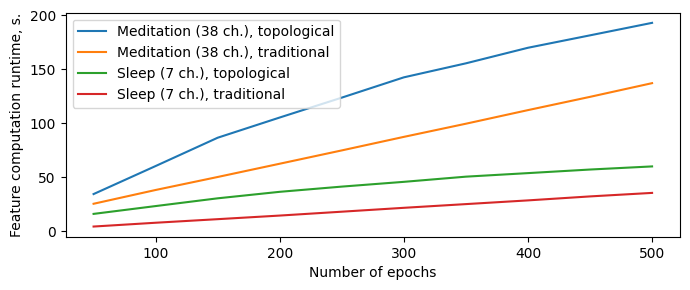

In [60]:
x = list(range(50, 501, 50))

def calc_scale(x, scale):
    if not scale:
        return 1
    return x / 600 + 11 / 12

def draw(file, label, scale = False):
    with open(file, "r") as file:
        data = eval(file.read())
    mean = [ get_ci(data[key])[0] / calc_scale(key, scale) for key in x ]
    plt.plot(x, mean, label = label)

plt.rcParams["figure.figsize"] = (7, 3)

draw("28-performance-meditation-topological.txt", "Meditation (38 ch.), topological", True)
draw("28-performance-meditation-traditional.txt", "Meditation (38 ch.), traditional")
draw("28-performance-sleep-topological.txt", "Sleep (7 ch.), topological", True)
draw("28-performance-sleep-traditional.txt", "Sleep (7 ch.), traditional")

plt.xlabel('Number of epochs')
plt.ylabel('Feature computation runtime, s.')
plt.legend()
plt.tight_layout()
plt.savefig("performance.svg")